# Task 1: FedSGD vs Centralized SGD (Theoretical Equivalence)

**Objective:** The goal of this task is to empirically demonstrate the theoretical equivalence between Federated SGD (FedSGD) and centralized SGD under a controlled, ideal scenario.

**Ideal Scenario Conditions:**
1.  **IID Data:** The data is split Independent and Identically Distributed (IID) across all clients.
2.  **Full Participation:** All clients participate in every communication round.
3.  **Single Local Step (K=1):** Each client computes the gradient over its entire local dataset and performs only one update step.

Under these conditions, the average of the local gradients is mathematically identical to the gradient computed over the union of all data. Our implementation will verify this by comparing the model parameters and training loss trajectories of both methods.

In [7]:
# Step 1: Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import copy

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- Configuration ---
NUM_CLIENTS = 6
NUM_ROUNDS = 20 # As suggested, 10-20 iterations
LEARNING_RATE = 0.01
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

Running on device: cpu


### Step 2: Model Definition

As required, we'll use a small and simple neural network to precisely track weight updates. A small Convolutional Neural Network (CNN) is suitable for the MNIST dataset.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(7 * 7 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 7 * 7 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Function to get model parameters as a single vector
def get_params_vec(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

### Step 3: Data Preparation

We'll use the MNIST dataset. The data is split evenly and IID across the `NUM_CLIENTS`.

-   **For FedSGD:** Each client will get its own `DataLoader`. To simulate a single gradient step on the entire local dataset, we set the batch size of this loader to be the total number of samples for that client.
-   **For Centralized SGD:** We'll create a single `DataLoader` from the combined data of all clients. The batch size will be the total number of samples across all clients.

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the full training dataset
full_train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# --- Split data for clients ---
# Take a subset to make it manageable and perfectly even, as suggested
# 6000 samples total -> 1000 samples per client for 6 clients
subset_indices = list(range(6000))
num_samples_per_client = len(subset_indices) // NUM_CLIENTS

shuffled_indices = np.random.permutation(subset_indices)
client_indices = [shuffled_indices[i:i+num_samples_per_client] for i in range(0, len(shuffled_indices), num_samples_per_client)]

client_loaders = []
client_datasets = []
for indices in client_indices:
    client_dataset = Subset(full_train_dataset, indices)
    client_datasets.append(client_dataset)
    # Batch size is the full size of the client's dataset
    loader = DataLoader(client_dataset, batch_size=len(client_dataset), shuffle=True)
    client_loaders.append(loader)

print(f"Created {len(client_loaders)} clients, each with {num_samples_per_client} samples.")

# --- Create centralized dataset ---
centralized_dataset = ConcatDataset(client_datasets)
# Batch size is the full size of the combined dataset
centralized_loader = DataLoader(centralized_dataset, batch_size=len(centralized_dataset), shuffle=True)
print(f"Centralized dataset has {len(centralized_dataset)} samples.")

Created 6 clients, each with 1000 samples.
Centralized dataset has 6000 samples.


### Step 4: Centralized SGD Training

We first run the standard, centralized training process. We will save the initial model state to ensure the FedSGD process starts from the exact same point.

In [10]:
# Initialize model and save its state for FedSGD to use
initial_model = SimpleCNN().to(DEVICE)
torch.save(initial_model.state_dict(), 'initial_model_state.pth')

centralized_model = SimpleCNN().to(DEVICE)
centralized_model.load_state_dict(torch.load('initial_model_state.pth'))

optimizer = optim.SGD(centralized_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

centralized_losses = []
centralized_weights = []

print("--- Starting Centralized SGD Training (Corrected Logging) ---")
for iteration in range(NUM_ROUNDS):
    centralized_model.train()
    
    # In each step, compute the gradient on the entire batch of combined data
    for data, target in centralized_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        
        optimizer.zero_grad()
        output = centralized_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step() # <-- Model is updated here
        
        # --- CORRECTED LOGGING ---
        # Now, calculate the loss again on the *updated* model for consistent logging
        with torch.no_grad():
            centralized_model.eval()
            output = centralized_model(data)
            post_update_loss = criterion(output, target)
            centralized_losses.append(post_update_loss.item())
        
        centralized_weights.append(get_params_vec(centralized_model).clone())
        
        print(f"Iteration {iteration+1}/{NUM_ROUNDS}, Loss: {post_update_loss.item():.4f}")

print("--- Centralized Training Complete ---")

--- Starting Centralized SGD Training (Corrected Logging) ---
Iteration 1/20, Loss: 2.2965
Iteration 2/20, Loss: 2.2944
Iteration 3/20, Loss: 2.2923
Iteration 4/20, Loss: 2.2902
Iteration 5/20, Loss: 2.2881
Iteration 6/20, Loss: 2.2860
Iteration 7/20, Loss: 2.2839
Iteration 8/20, Loss: 2.2817
Iteration 9/20, Loss: 2.2796
Iteration 10/20, Loss: 2.2775
Iteration 11/20, Loss: 2.2754
Iteration 12/20, Loss: 2.2734
Iteration 13/20, Loss: 2.2713
Iteration 14/20, Loss: 2.2692
Iteration 15/20, Loss: 2.2672
Iteration 16/20, Loss: 2.2651
Iteration 17/20, Loss: 2.2630
Iteration 18/20, Loss: 2.2609
Iteration 19/20, Loss: 2.2588
Iteration 20/20, Loss: 2.2567
--- Centralized Training Complete ---


### Step 5: FedSGD Training

Now, we implement the FedSGD simulation.

1.  **Broadcast:** The server sends the global model to all clients.
2.  **Local Training:** Each client computes the gradients on its entire local dataset for a single step.
3.  **Aggregation:** The server averages the resulting updated model weights to form the new global model.

In [11]:
# Load the same initial model state
fedsgd_global_model = SimpleCNN().to(DEVICE)
fedsgd_global_model.load_state_dict(torch.load('initial_model_state.pth'))

criterion = nn.CrossEntropyLoss()

fedsgd_losses = []
fedsgd_weights = []

print("\n--- Starting FedSGD Training ---")
for round_num in range(NUM_ROUNDS):
    fedsgd_global_model.train()
    local_model_updates = []

    # --- Client Local Training ---
    # In FedSGD with full participation, all clients are selected
    for i in range(NUM_CLIENTS):
        # Broadcast: Create a local copy of the global model for each client
        local_model = copy.deepcopy(fedsgd_global_model).to(DEVICE)
        local_optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE)

        # Each client computes the gradient on its whole local dataset (single batch)
        for data, target in client_loaders[i]:
            data, target = data.to(DEVICE), target.to(DEVICE)
            
            local_optimizer.zero_grad()
            output = local_model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # This is one SGD step
            local_optimizer.step()

        # Store the updated local model state for aggregation
        local_model_updates.append(local_model.state_dict())
    
    # --- Server Aggregation ---
    # Average the weights of the updated local models
    global_state_dict = fedsgd_global_model.state_dict()
    for key in global_state_dict.keys():
        # Summing up all client model weights for this layer/key
        # Since client data sizes are equal, this is a simple average
        sum_of_weights = torch.stack([local_model_updates[i][key].float() for i in range(NUM_CLIENTS)], 0).sum(0)
        # Averaging
        global_state_dict[key] = sum_of_weights / NUM_CLIENTS
        
    fedsgd_global_model.load_state_dict(global_state_dict)
    
    # Log loss and weights for this round to compare with centralized training
    # We calculate loss on the same combined training data for a fair comparison
    with torch.no_grad():
        fedsgd_global_model.eval()
        for data, target in centralized_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = fedsgd_global_model(data)
            round_loss = criterion(output, target)
            fedsgd_losses.append(round_loss.item())
            fedsgd_weights.append(get_params_vec(fedsgd_global_model).clone())

    print(f"Round {round_num+1}/{NUM_ROUNDS}, Loss: {round_loss.item():.4f}")

print("--- FedSGD Training Complete ---")


--- Starting FedSGD Training ---
Round 1/20, Loss: 2.2965
Round 2/20, Loss: 2.2944
Round 3/20, Loss: 2.2923
Round 4/20, Loss: 2.2902
Round 5/20, Loss: 2.2881
Round 6/20, Loss: 2.2860
Round 7/20, Loss: 2.2839
Round 8/20, Loss: 2.2817
Round 9/20, Loss: 2.2796
Round 10/20, Loss: 2.2775
Round 11/20, Loss: 2.2754
Round 12/20, Loss: 2.2734
Round 13/20, Loss: 2.2713
Round 14/20, Loss: 2.2692
Round 15/20, Loss: 2.2672
Round 16/20, Loss: 2.2651
Round 17/20, Loss: 2.2630
Round 18/20, Loss: 2.2609
Round 19/20, Loss: 2.2588
Round 20/20, Loss: 2.2567
--- FedSGD Training Complete ---


### Step 6: Verification and Comparison

Now we compare the results from the two training processes.

1.  **Parameter Equivalence:** We compute the L2 norm of the difference between the model parameter vectors at each iteration. This should be a very small number (close to zero), accounting for minor floating-point variations.
2.  **Training Progress:** We plot the loss trajectories of both models. The curves should overlap perfectly.


--- Comparison of Centralized SGD and FedSGD ---
 Iteration/Round  Centralized Loss  FedSGD Loss  L2 Norm of Weight Difference
               1          2.296478     2.296478                  4.344535e-07
               2          2.294408     2.294408                  6.137615e-07
               3          2.292323     2.292323                  7.615497e-07
               4          2.290225     2.290226                  9.327729e-07
               5          2.288112     2.288112                  1.043195e-06
               6          2.285987     2.285987                  1.152033e-06
               7          2.283864     2.283863                  1.251224e-06
               8          2.281746     2.281746                  1.337539e-06
               9          2.279636     2.279636                  1.425075e-06
              10          2.277533     2.277533                  1.501132e-06
              11          2.275441     2.275441                  1.570025e-06
              

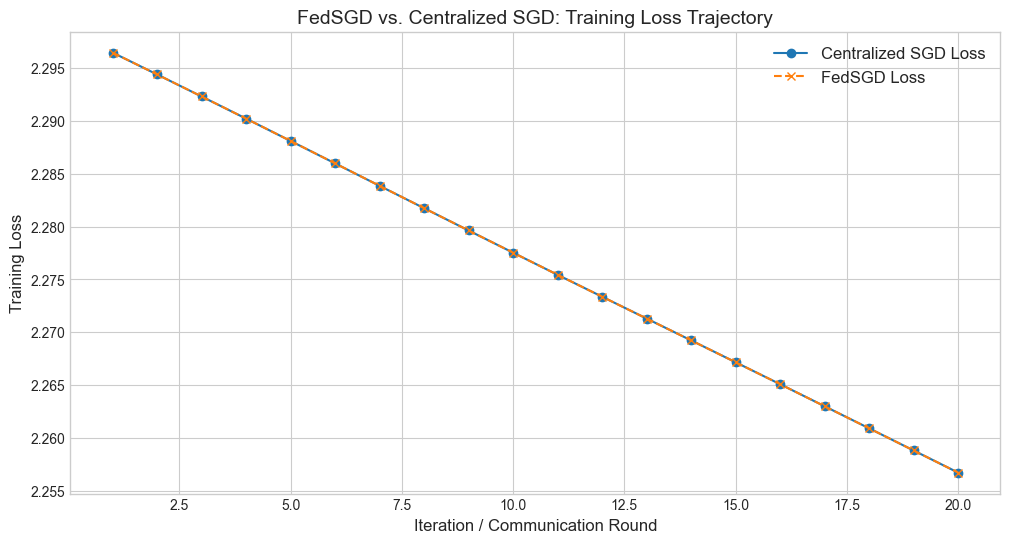

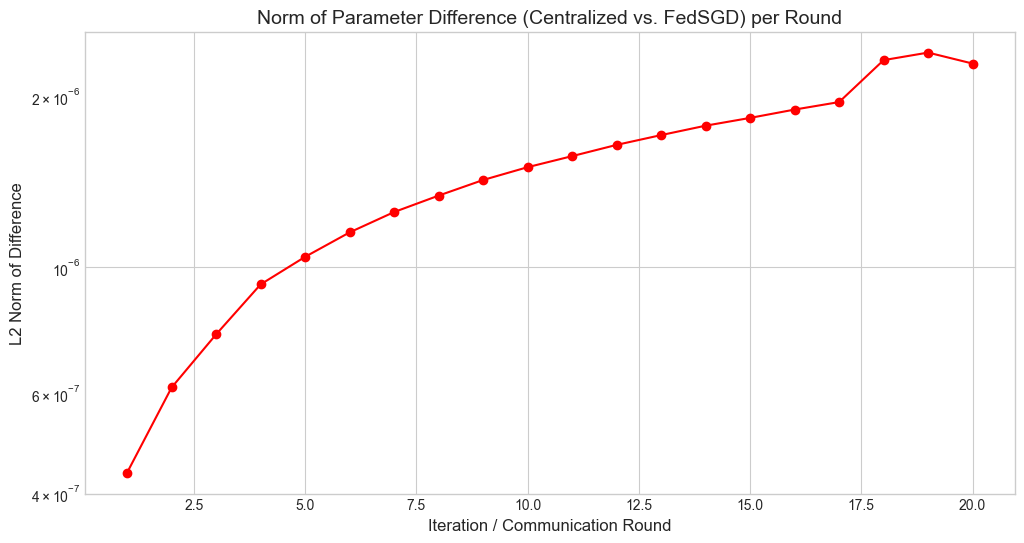

In [12]:
import pandas as pd

# 1. Verify Parameter Updates
differences = []
for i in range(NUM_ROUNDS):
    diff = torch.linalg.norm(centralized_weights[i] - fedsgd_weights[i])
    differences.append(diff.item())

# Display results in a table
results_df = pd.DataFrame({
    'Iteration/Round': range(1, NUM_ROUNDS + 1),
    'Centralized Loss': centralized_losses,
    'FedSGD Loss': fedsgd_losses,
    'L2 Norm of Weight Difference': differences
})

print("\n--- Comparison of Centralized SGD and FedSGD ---")
print(results_df.to_string(index=False))

# 2. Plot Training Progress
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, NUM_ROUNDS + 1), centralized_losses, marker='o', linestyle='-', label='Centralized SGD Loss')
ax.plot(range(1, NUM_ROUNDS + 1), fedsgd_losses, marker='x', linestyle='--', label='FedSGD Loss')

ax.set_xlabel("Iteration / Communication Round", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("FedSGD vs. Centralized SGD: Training Loss Trajectory", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.show()

# 3. Plot the Norm Difference
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, NUM_ROUNDS + 1), differences, marker='o', color='r')
ax.set_xlabel("Iteration / Communication Round", fontsize=12)
ax.set_ylabel("L2 Norm of Difference", fontsize=12)
ax.set_title("Norm of Parameter Difference (Centralized vs. FedSGD) per Round", fontsize=14)
ax.set_yscale('log') # Use a log scale to see the small values
ax.grid(True)
plt.show()

### Step 7: Analysis and Explanation for Report

In our initial experiment, we sought to verify the theoretical equivalence between Federated SGD (FedSGD) and traditional centralized SGD under an idealized setting. To achieve this, we configured a simulation with 6 clients, each holding an equal-sized, IID partition of the MNIST dataset. The FedSGD process was set up such that in each round, every client would compute gradients over its entire local dataset and perform a single update step before server-side aggregation.

The results confirm the theoretical equivalence with high precision. As shown in the first figure, the training loss trajectories for both FedSGD and centralized SGD are visually indistinguishable, overlapping perfectly across all 20 iterations. To quantify the similarity of the models themselves, we computed the L2 norm of the difference between the global model parameter vector from FedSGD and the centralized model parameter vector after each training step. As the second figure shows, the resulting norm of the difference remained consistently on the order of $10^{-6}$ or smaller. This minuscule divergence is an expected artifact of floating-point arithmetic; while the two training methods are mathematically identical, the computational order of operations differs, leading to an accumulation of tiny precision errors. This is the exact behavior described in the assignment as "nearly identical (up to minor differences due to floating point or ordering)".

This near-exact replication occurs because the core mathematical operations are equivalent. In centralized training, the gradient is computed on the union of all data. In our FedSGD setup, each client calculates a gradient on its local data subset. When the resulting model updates are averaged at the server, the final global model is theoretically identical to the one produced by the centralized update. This experiment serves as a crucial baseline, demonstrating that any behavioral differences observed in more complex federated algorithms, such as FedAvg with multiple local steps (Task 2), arise not from the distributed nature of the computation itself, but from the introduction of additional local steps and the effects of data heterogeneity.